# 1D-CNN 기반 네트워크 침입 탐지 (v3 - Multi-scale + SE Attention)

**변경 사항 (v1/v2 대비)**
- Loss: `CrossEntropyLoss` + **약한 class_weight** (v2 Focal Loss 실패 → v1 방식 복귀)
- 모델: **Multi-scale Conv (k=1,3,5)** + **Residual Connection** + **SE Attention** + **강화된 분류기**
- Infiltration에 2~3배 가중치 부여 (과도한 역비례 alpha 제거)
- 체크포인트: `checkpoint_v3.pt` / `best_model_v3.pt`

---
### 순서
1. 라이브러리 임포트
2. 데이터 로드 & 분할
3. Dataset / DataLoader 정의
4. Multi-scale CNN1D 모델 정의 (v3)
5. 손실 함수 정의 (CrossEntropyLoss + class_weight)
6. 학습
7. 평가 (Confusion Matrix, Classification Report)
8. 모델 저장

## 1. 라이브러리 임포트

In [1]:
import os
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# 한글 폰트 설정 (Windows)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 재현성 고정
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU             : {torch.cuda.get_device_name(0)}")

PyTorch version : 2.11.0+cu126
Device          : cuda
GPU             : NVIDIA GeForce RTX 4050 Laptop GPU


## 2. 데이터 로드 & 분할

In [2]:
BASE_DIR   = os.path.dirname(os.path.abspath("__file__"))
OUTPUT_DIR = os.path.join(BASE_DIR, "processed")
MODEL_DIR  = os.path.join(BASE_DIR, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

X = np.load(os.path.join(OUTPUT_DIR, "X.npy"))
y = np.load(os.path.join(OUTPUT_DIR, "y.npy"))

with open(os.path.join(OUTPUT_DIR, "label_mapping.json"), encoding="utf-8") as f:
    label_mapping = json.load(f)

idx2label   = {v: k for k, v in label_mapping.items()}
class_names = [idx2label[i] for i in range(len(idx2label))]
num_classes = len(class_names)

print(f"X shape     : {X.shape}")
print(f"y shape     : {y.shape}")
print(f"클래스 수   : {num_classes}")
print(f"클래스 목록 : {class_names}")

# Train 70 / Val 15 / Test 15
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp)

print(f"\nTrain : {X_train.shape[0]:,}")
print(f"Val   : {X_val.shape[0]:,}")
print(f"Test  : {X_test.shape[0]:,}")

X shape     : (2330915, 70)
y shape     : (2330915,)
클래스 수   : 7
클래스 목록 : ['Benign', 'Bot', 'Brute Force', 'DDoS', 'DoS', 'Infiltration', 'SQL Injection']

Train : 1,631,640
Val   : 349,637
Test  : 349,638


## 3. Dataset / DataLoader 정의

In [3]:
class IDSDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 512

train_loader = DataLoader(IDSDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(IDSDataset(X_val,   y_val),   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(IDSDataset(X_test,  y_test),  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")
print(f"Test  batches : {len(test_loader)}")

Train batches : 3187
Val   batches : 683
Test  batches : 683


## 4. Multi-scale CNN1D 모델 정의 (v3)

v1 대비 개선점:
1. **Multi-scale Conv (k=1,3,5)** — 다양한 패턴 동시 포착
2. **Residual Connection** — 깊은 네트워크도 안정적 학습
3. **SE (Squeeze-and-Excitation) Attention** — 중요 채널에 집중
4. **강화된 분류기** — 2층 FC + BN + Dropout

In [4]:
class CNN1D_v3(nn.Module):
    def __init__(self, num_features, num_classes, dropout=0.3):
        super().__init__()

        # ── Multi-scale 1st block ──
        self.conv1_k1 = nn.Conv1d(1, 32, kernel_size=1)
        self.conv1_k3 = nn.Conv1d(1, 32, kernel_size=3, padding=1)
        self.conv1_k5 = nn.Conv1d(1, 32, kernel_size=5, padding=2)
        # concat → 96ch
        self.bn1   = nn.BatchNorm1d(96)
        self.pool1 = nn.MaxPool1d(2)

        # ── Residual Block ──
        self.conv2  = nn.Conv1d(96, 128, kernel_size=3, padding=1)
        self.bn2    = nn.BatchNorm1d(128)
        self.conv2b = nn.Conv1d(128, 128, kernel_size=3, padding=1)
        self.bn2b   = nn.BatchNorm1d(128)
        self.skip2  = nn.Conv1d(96, 128, kernel_size=1)  # 채널 맞추기
        self.pool2  = nn.MaxPool1d(2)

        # ── SE Attention + Conv3 ──
        self.conv3 = nn.Conv1d(128, 256, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm1d(256)
        # Squeeze-and-Excitation
        self.se_fc1 = nn.Linear(256, 64)
        self.se_fc2 = nn.Linear(64, 256)

        self.global_pool = nn.AdaptiveAvgPool1d(1)

        # ── 강화된 분류기 ──
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        # Multi-scale
        x = torch.cat([self.conv1_k1(x), self.conv1_k3(x), self.conv1_k5(x)], dim=1)
        x = self.pool1(torch.relu(self.bn1(x)))

        # Residual
        identity = self.skip2(x)
        x = torch.relu(self.bn2(self.conv2(x)))
        x = self.bn2b(self.conv2b(x))
        x = self.pool2(torch.relu(x + identity))

        # SE Attention
        x = torch.relu(self.bn3(self.conv3(x)))
        se = self.global_pool(x).squeeze(-1)
        se = torch.relu(self.se_fc1(se))
        se = torch.sigmoid(self.se_fc2(se)).unsqueeze(-1)
        x = x * se

        x = self.global_pool(x)
        return self.classifier(x)


num_features = X_train.shape[1]
model = CNN1D_v3(num_features=num_features, num_classes=num_classes).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"학습 가능 파라미터 수: {total_params:,}")
print(f"\n모델 구조:\n{model}")

학습 가능 파라미터 수: 332,039

모델 구조:
CNN1D_v3(
  (conv1_k1): Conv1d(1, 32, kernel_size=(1,), stride=(1,))
  (conv1_k3): Conv1d(1, 32, kernel_size=(3,), stride=(1,), padding=(1,))
  (conv1_k5): Conv1d(1, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn1): BatchNorm1d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(96, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2b): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn2b): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (skip2): Conv1d(96, 128, kernel_size=(1,), stride=(1,))
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn3): BatchNorm1d(256, eps=1e-05,

## 5. 손실 함수 정의 (CrossEntropyLoss + class_weight)

v1 vs v2 vs v3 전략 비교:
- **v1**: CrossEntropyLoss (가중치 없음) → 91.3% accuracy, Infiltration recall 26.3%
- **v2**: Focal Loss (극단적 alpha) → 45.5% accuracy ❌ 실패
- **v3**: CrossEntropyLoss + **온건한 class_weight** → Infiltration에만 2~3배 가중치

In [5]:
# ── 온건한 class_weight: Infiltration/SQL Injection에만 약간의 가중치 ──
train_counts = torch.zeros(num_classes)
for i in range(num_classes):
    train_counts[i] = (torch.tensor(y_train) == i).sum()

# 기본 가중치 1.0, 소수 클래스만 상향
median_count = train_counts.median()
weights = torch.clamp(median_count / train_counts, min=1.0, max=3.0).to(DEVICE)

print("클래스별 가중치 (온건한 class_weight):")
for i, (name, w, cnt) in enumerate(zip(class_names, weights, train_counts)):
    print(f"  {i} {name:<15}: weight={w:.4f}  (샘플 수: {int(cnt):,})")

criterion = nn.CrossEntropyLoss(weight=weights)
print(f"\nCrossEntropyLoss + 온건한 class_weight 적용 완료")

클래스별 가중치 (온건한 class_weight):
  0 Benign         : weight=1.0000  (샘플 수: 350,000)
  1 Bot            : weight=1.3340  (샘플 수: 200,333)
  2 Brute Force    : weight=1.0000  (샘플 수: 267,253)
  3 DDoS           : weight=1.0000  (샘플 수: 350,000)
  4 DoS            : weight=1.0000  (샘플 수: 350,000)
  5 Infiltration   : weight=2.3577  (샘플 수: 113,354)
  6 SQL Injection  : weight=3.0000  (샘플 수: 700)

CrossEntropyLoss + 온건한 class_weight 적용 완료


## 6. 학습

In [6]:
EPOCHS   = 50
LR       = 1e-3
PATIENCE = 7

CKPT_PATH = os.path.join(MODEL_DIR, "checkpoint_v3.pt")
BEST_PATH = os.path.join(MODEL_DIR, "best_model_v3.pt")

optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss = float("inf")
patience_cnt  = 0
start_epoch   = 1

# 체크포인트 복원
if os.path.exists(CKPT_PATH):
    ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    scheduler.load_state_dict(ckpt["scheduler_state"])
    history       = ckpt["history"]
    best_val_loss = ckpt["best_val_loss"]
    patience_cnt  = ckpt["patience_cnt"]
    start_epoch   = ckpt["epoch"] + 1
    print(f"체크포인트 복원 완료 → epoch {ckpt['epoch']} 이후부터 재시작")
else:
    print("체크포인트 없음 → 처음부터 학습 (v3 Multi-scale + SE Attention)")

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            total_loss += loss.item() * len(y_batch)
            correct    += (logits.argmax(1) == y_batch).sum().item()
            total      += len(y_batch)
    return total_loss / total, correct / total


for epoch in range(start_epoch, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    vl_loss, vl_acc = run_epoch(val_loader,   train=False)
    scheduler.step(vl_loss)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    marker = " ★" if vl_loss < best_val_loss else ""
    print(f"Epoch {epoch:02d}/{EPOCHS}  "
          f"train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  "
          f"val_loss={vl_loss:.4f}  val_acc={vl_acc:.4f}{marker}")

    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        patience_cnt  = 0
        torch.save(model.state_dict(), BEST_PATH)
    else:
        patience_cnt += 1

    torch.save({
        "epoch"           : epoch,
        "model_state"     : model.state_dict(),
        "optimizer_state" : optimizer.state_dict(),
        "scheduler_state" : scheduler.state_dict(),
        "history"         : history,
        "best_val_loss"   : best_val_loss,
        "patience_cnt"    : patience_cnt,
    }, CKPT_PATH)

    if patience_cnt >= PATIENCE:
        print(f"\nEarly Stopping (patience={PATIENCE})")
        break

print("\n학습 완료. Best val_loss:", round(best_val_loss, 6))

체크포인트 없음 → 처음부터 학습 (v3 Multi-scale + SE Attention)
Epoch 01/50  train_loss=0.2587  train_acc=0.8931  val_loss=0.2457  val_acc=0.8971 ★
Epoch 02/50  train_loss=0.2384  train_acc=0.9005  val_loss=0.2458  val_acc=0.9047
Epoch 03/50  train_loss=0.2338  train_acc=0.9020  val_loss=0.2384  val_acc=0.8995 ★
Epoch 04/50  train_loss=0.2319  train_acc=0.9031  val_loss=0.2319  val_acc=0.8986 ★
Epoch 05/50  train_loss=0.2300  train_acc=0.9035  val_loss=0.2327  val_acc=0.9023
Epoch 06/50  train_loss=0.2290  train_acc=0.9035  val_loss=0.2403  val_acc=0.9062
Epoch 07/50  train_loss=0.2277  train_acc=0.9040  val_loss=0.2331  val_acc=0.9048
Epoch 08/50  train_loss=0.2269  train_acc=0.9043  val_loss=0.4394  val_acc=0.7592
Epoch 09/50  train_loss=0.2260  train_acc=0.9039  val_loss=0.2475  val_acc=0.9052
Epoch 10/50  train_loss=0.2251  train_acc=0.9040  val_loss=0.2277  val_acc=0.9050 ★
Epoch 11/50  train_loss=0.2243  train_acc=0.9042  val_loss=0.2771  val_acc=0.8945
Epoch 12/50  train_loss=0.2238  train_a

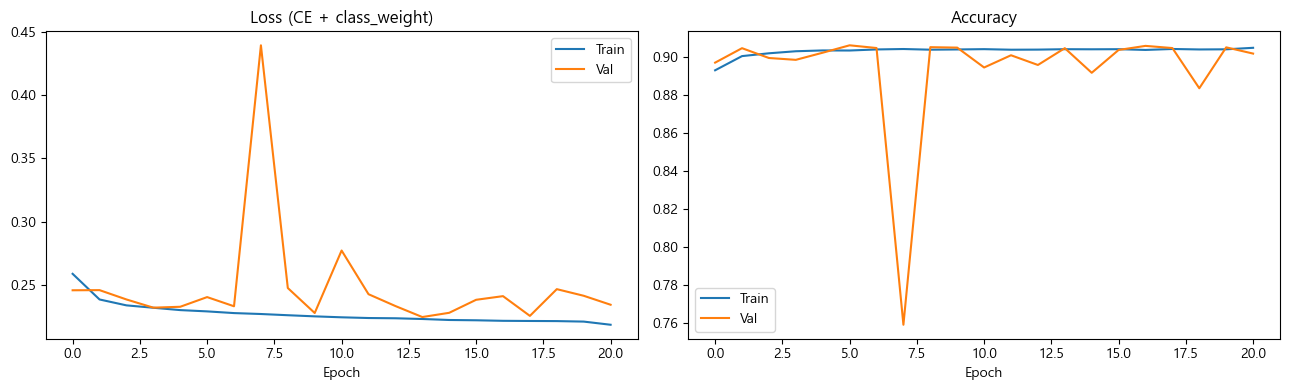

In [7]:
# Loss / Accuracy 커브
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"],   label="Val")
axes[0].set_title("Loss (CE + class_weight)")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["train_acc"], label="Train")
axes[1].plot(history["val_acc"],   label="Val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. 평가

In [8]:
model.load_state_dict(torch.load(BEST_PATH, map_location=DEVICE, weights_only=True))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds = model(X_batch.to(DEVICE)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print("=== Classification Report (v3 - Multi-scale + SE + class_weight) ===")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

=== Classification Report (v3 - Multi-scale + SE + class_weight) ===
               precision    recall  f1-score   support

       Benign     0.8373    0.8737    0.8551     75000
          Bot     1.0000    0.9999    0.9999     42929
  Brute Force     0.8605    0.9582    0.9067     57269
         DDoS     0.9999    0.9997    0.9998     75000
          DoS     0.9657    0.8817    0.9218     75000
 Infiltration     0.5514    0.4780    0.5121     24290
SQL Injection     0.8315    0.9867    0.9024       150

     accuracy                         0.9043    349638
    macro avg     0.8638    0.8825    0.8711    349638
 weighted avg     0.9036    0.9043    0.9029    349638



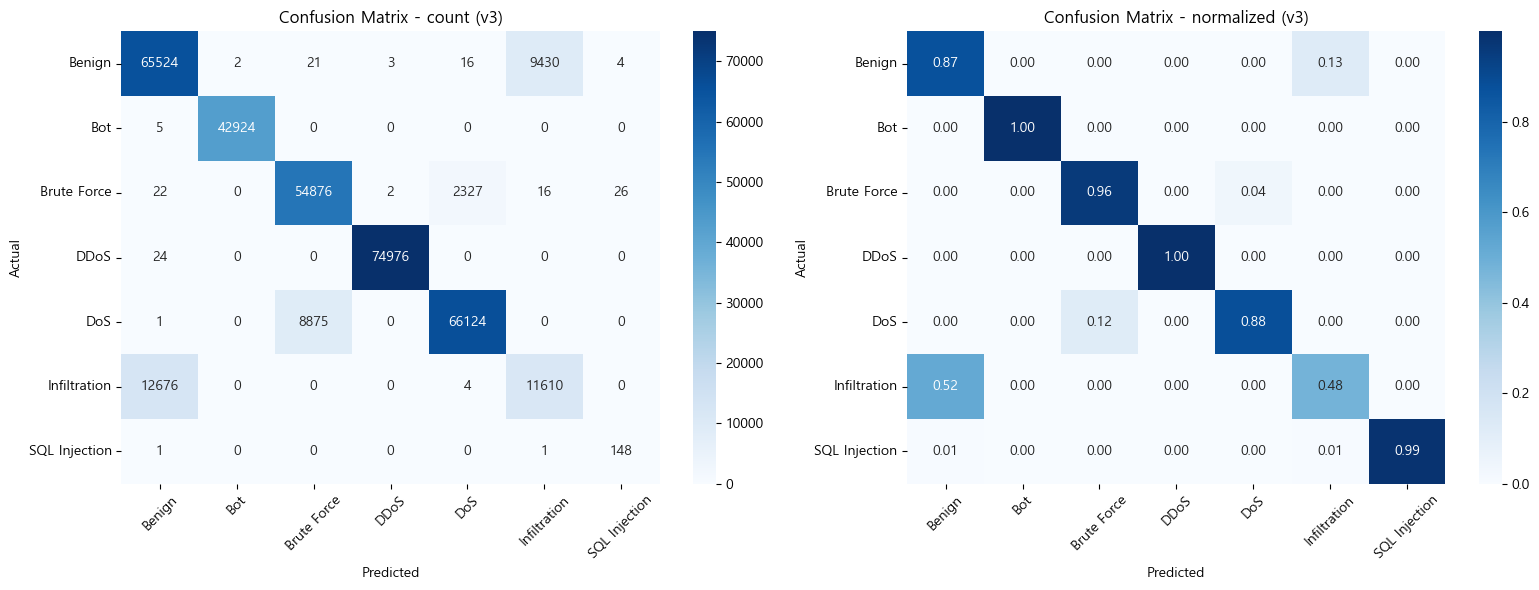

In [9]:
# Confusion Matrix
cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title("Confusion Matrix - count (v3)")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
axes[0].tick_params(axis="x", rotation=45)

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title("Confusion Matrix - normalized (v3)")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 8. 모델 저장

In [10]:
meta = {
    "version"        : "v3",
    "loss"           : "CrossEntropyLoss + class_weight",
    "architecture"   : "CNN1D_v3 (Multi-scale + Residual + SE Attention)",
    "num_features"   : num_features,
    "num_classes"    : num_classes,
    "class_names"    : class_names,
    "label_mapping"  : label_mapping,
    "batch_size"     : BATCH_SIZE,
    "epochs_trained" : len(history["train_loss"]),
    "best_val_loss"  : round(best_val_loss, 6),
}
with open(os.path.join(MODEL_DIR, "model_meta_v3.json"), "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("저장 완료!")
print(f"  models/best_model_v3.pt   — v3 가중치")
print(f"  models/model_meta_v3.json — v3 메타데이터")

저장 완료!
  models/best_model_v3.pt   — v3 가중치
  models/model_meta_v3.json — v3 메타데이터
